In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings('ignore')

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
DEVICE   = torch.device('cpu')
SEQ_LEN  = 48      
BATCH    = 64
EPOCHS   = 100       
LR       = 1e-3
HIDDEN   = 128      
LAYERS   = 2
DROPOUT  = 0.3      
 
TIME_FEATS = ['hour_sin','hour_cos','dow_sin','dow_cos',
              'month_sin','month_cos','is_weekend','is_night']
INPUT_SIZE = 1 + len(TIME_FEATS)  

In [4]:
def add_time_features(df):
    df = df.copy()
    h = df['DateTime'].dt.hour
    dow = df['DateTime'].dt.dayofweek
    m = df['DateTime'].dt.month
    df['hour_sin']   = np.sin(2*np.pi*h/24)
    df['hour_cos']   = np.cos(2*np.pi*h/24)
    df['dow_sin']    = np.sin(2*np.pi*dow/7)
    df['dow_cos']    = np.cos(2*np.pi*dow/7)
    df['month_sin']  = np.sin(2*np.pi*m/12)
    df['month_cos']  = np.cos(2*np.pi*m/12)
    df['is_weekend'] = dow.isin([5,6]).astype(float)
    df['is_night']   = h.isin(list(range(0,6)) + list(range(22,24))).astype(float)
    return df
 
train_raw = pd.read_csv(r'C:\Users\LENOVO\Desktop\Traffic-Pattern-Forecasting\data\raw\train_aWnotuB.csv', parse_dates=['DateTime'])
test_raw  = pd.read_csv(r'C:\Users\LENOVO\Desktop\Traffic-Pattern-Forecasting\data\raw\datasets_8494_11879_test_BdBKkAj.csv', parse_dates=['DateTime'])
train_raw = add_time_features(train_raw)
test_raw  = add_time_features(test_raw)

In [5]:
VAL_START = '2017-05-01'
tr_df  = train_raw[train_raw['DateTime'] <  VAL_START].copy()
val_df = train_raw[train_raw['DateTime'] >= VAL_START].copy()

In [6]:
def build_sequences(df, scalers, seq_len, fit=False):
    all_X, all_y, all_meta = [], [], []
 
    for j in sorted(df['Junction'].unique()):
        jdf = df[df['Junction']==j].sort_values('DateTime').reset_index(drop=True)
        vehicles = jdf['Vehicles'].values.reshape(-1,1)
 
        if fit:
            sc = MinMaxScaler()
            v_sc = sc.fit_transform(vehicles).flatten()
            scalers[j] = sc
        else:
            v_sc = scalers[j].transform(vehicles).flatten()
 
        tf = jdf[TIME_FEATS].values
        combined = np.concatenate([v_sc.reshape(-1,1), tf], axis=1)  # (N, 9)
 
        for i in range(seq_len, len(combined)):
            all_X.append(combined[i-seq_len:i])
            all_y.append(v_sc[i])
            all_meta.append(j)
 
    return (np.array(all_X, dtype=np.float32),
            np.array(all_y, dtype=np.float32),
            np.array(all_meta))
 
scalers = {}
X_tr, y_tr, _ = build_sequences(tr_df,  scalers, SEQ_LEN, fit=True)
X_val,y_val,meta_val = build_sequences(val_df, scalers, SEQ_LEN, fit=False)
 
print(f"Train seqs : {len(X_tr):,}  shape {X_tr[0].shape}")
print(f"Val seqs   : {len(X_val):,}")

Train seqs : 42,072  shape (48, 9)
Val seqs   : 5,664


In [7]:
class TrafficDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]
 
train_dl = DataLoader(TrafficDS(X_tr, y_tr),   batch_size=BATCH, shuffle=True,  num_workers=0)
val_dl   = DataLoader(TrafficDS(X_val, y_val), batch_size=BATCH, shuffle=False, num_workers=0)

In [8]:
class TrafficLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(INPUT_SIZE, HIDDEN, LAYERS,
                            batch_first=True, dropout=DROPOUT)
        self.norm = nn.LayerNorm(HIDDEN)
        self.fc   = nn.Linear(HIDDEN, 1)
 
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.norm(out[:, -1, :])   
        return self.fc(out).squeeze(1)
 
model = TrafficLSTM().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params:,}")
 
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-5
)
criterion = nn.MSELoss()

Model params: 203,649


In [9]:
train_losses, val_losses, lr_history = [], [], []
best_val_loss = float('inf')
best_state    = None
t_start       = time.time()
 
for epoch in range(1, EPOCHS+1):
    # Train
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(train_dl.dataset)
 
    # Validate
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            v_loss += criterion(model(xb.to(DEVICE)), yb.to(DEVICE)).item() * len(xb)
    v_loss /= len(val_dl.dataset)
 
    scheduler.step(v_loss)
    current_lr = optimizer.param_groups[0]['lr']
 
    train_losses.append(epoch_loss)
    val_losses.append(v_loss)
    lr_history.append(current_lr)
 
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
 
    if epoch % 5 == 0:
        elapsed = (time.time()-t_start)/60
        print(f"Epoch {epoch:02d}/{EPOCHS} | "
              f"Train: {epoch_loss:.5f} | Val: {v_loss:.5f} | "
              f"LR: {current_lr:.6f} | Elapsed: {elapsed:.1f}min")
 
model.load_state_dict(best_state)
print(f"\nBest val loss (MSE scaled): {best_val_loss:.5f}")

Epoch 05/100 | Train: 0.00220 | Val: 0.00519 | LR: 0.001000 | Elapsed: 3.4min
Epoch 10/100 | Train: 0.00198 | Val: 0.00497 | LR: 0.001000 | Elapsed: 6.7min
Epoch 15/100 | Train: 0.00178 | Val: 0.00444 | LR: 0.000500 | Elapsed: 9.8min
Epoch 20/100 | Train: 0.00176 | Val: 0.00391 | LR: 0.000250 | Elapsed: 13.1min
Epoch 25/100 | Train: 0.00165 | Val: 0.00395 | LR: 0.000250 | Elapsed: 16.5min
Epoch 30/100 | Train: 0.00158 | Val: 0.00395 | LR: 0.000125 | Elapsed: 20.0min
Epoch 35/100 | Train: 0.00156 | Val: 0.00384 | LR: 0.000063 | Elapsed: 23.3min
Epoch 40/100 | Train: 0.00153 | Val: 0.00378 | LR: 0.000031 | Elapsed: 26.7min
Epoch 45/100 | Train: 0.00153 | Val: 0.00385 | LR: 0.000016 | Elapsed: 30.0min
Epoch 50/100 | Train: 0.00153 | Val: 0.00384 | LR: 0.000016 | Elapsed: 33.0min
Epoch 55/100 | Train: 0.00152 | Val: 0.00397 | LR: 0.000010 | Elapsed: 36.1min
Epoch 60/100 | Train: 0.00152 | Val: 0.00390 | LR: 0.000010 | Elapsed: 39.2min
Epoch 65/100 | Train: 0.00151 | Val: 0.00373 | LR: 0.00

In [10]:
model.eval()
preds_scaled = []
with torch.no_grad():
    for xb, _ in val_dl:
        preds_scaled.extend(model(xb.to(DEVICE)).cpu().numpy())
 
preds_scaled = np.array(preds_scaled)
true_scaled  = y_val
 
# Inverse transform per junction
preds_real = np.zeros_like(preds_scaled)
true_real  = np.zeros_like(true_scaled)
for j in sorted(scalers.keys()):
    mask = meta_val == j
    preds_real[mask] = scalers[j].inverse_transform(
        preds_scaled[mask].reshape(-1,1)).flatten()
    true_real[mask]  = scalers[j].inverse_transform(
        true_scaled[mask].reshape(-1,1)).flatten()
 
preds_real = np.clip(preds_real, 0, None)
 
rmse = np.sqrt(mean_squared_error(true_real, preds_real))
mae  = mean_absolute_error(true_real, preds_real)
print(f"\nVal RMSE : {rmse:.3f}")
print(f"Val MAE  : {mae:.3f}")
 
# Per-junction RMSE
print("\nPer-Junction RMSE:")
for j in sorted(scalers.keys()):
    mask = meta_val == j
    r = np.sqrt(mean_squared_error(true_real[mask], preds_real[mask]))
    print(f"  Junction {j}: {r:.3f}")


Val RMSE : 4.603
Val MAE  : 2.812

Per-Junction RMSE:
  Junction 1: 5.929
  Junction 2: 3.221
  Junction 3: 5.702
  Junction 4: 2.590


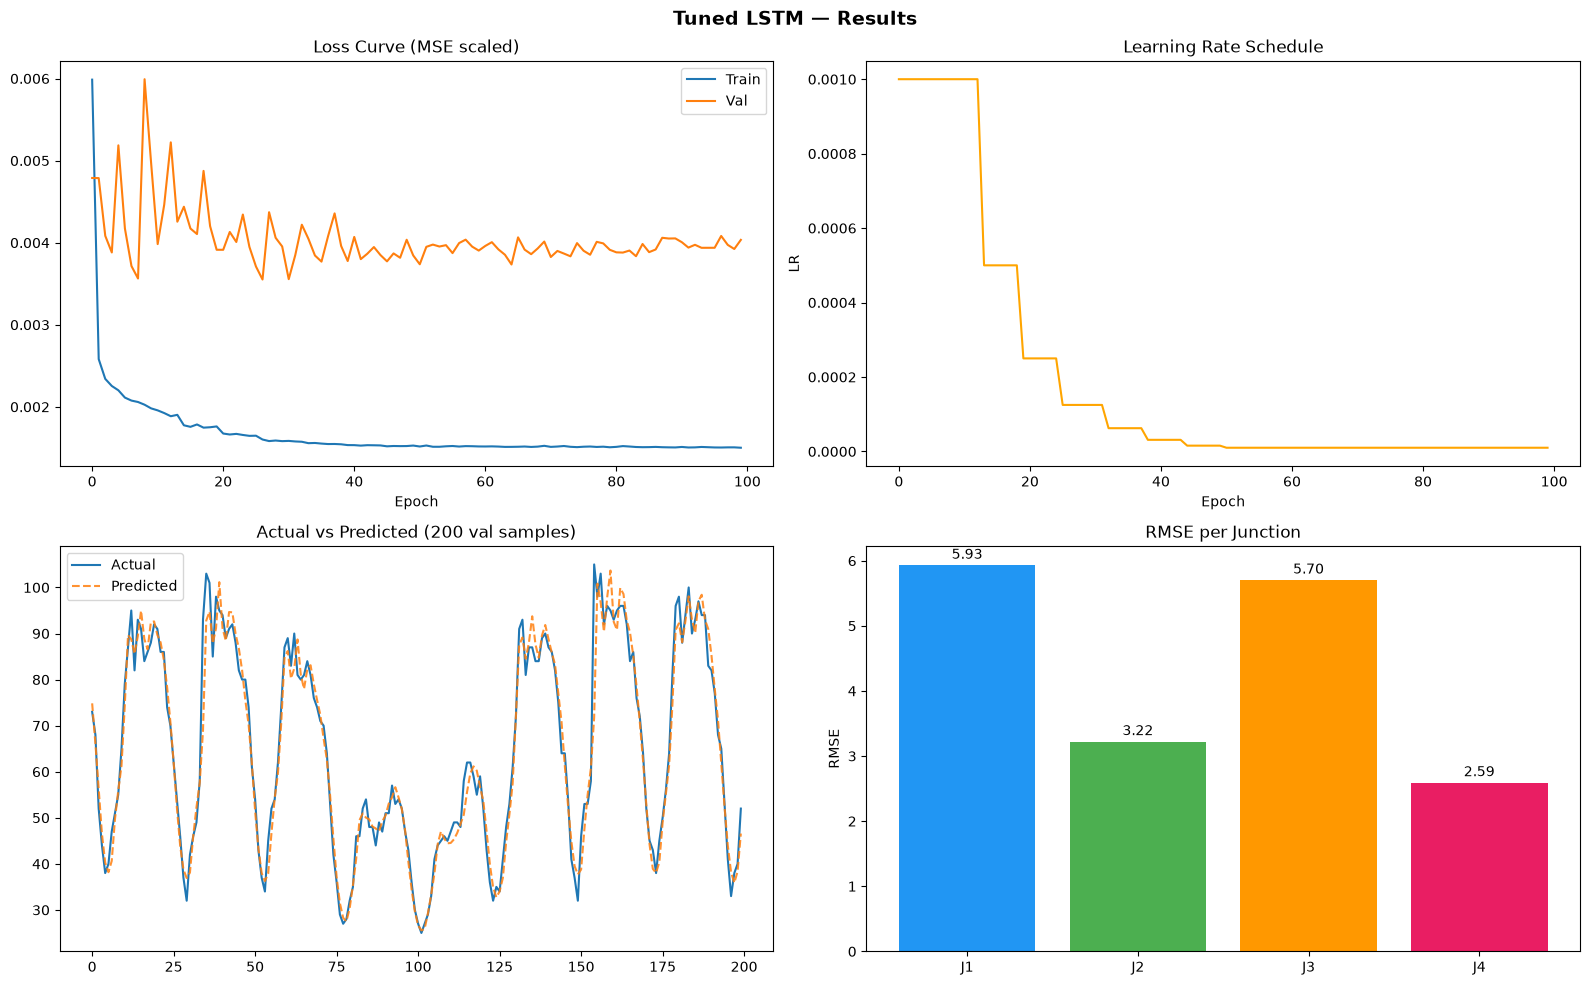

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Tuned LSTM — Results', fontsize=14, fontweight='bold')
 
# Loss curve
axes[0,0].plot(train_losses, label='Train')
axes[0,0].plot(val_losses,   label='Val')
axes[0,0].set_title('Loss Curve (MSE scaled)'); axes[0,0].legend()
axes[0,0].set_xlabel('Epoch')
 
# LR curve
axes[0,1].plot(lr_history, color='orange')
axes[0,1].set_title('Learning Rate Schedule')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('LR')
 
# Actual vs Predicted — overall sample
n = min(200, len(true_real))
axes[1,0].plot(true_real[:n],  label='Actual')
axes[1,0].plot(preds_real[:n], label='Predicted', linestyle='--', alpha=0.85)
axes[1,0].set_title('Actual vs Predicted (200 val samples)')
axes[1,0].legend()
 
# Per-junction RMSE bar
junctions = sorted(scalers.keys())
j_rmses = [np.sqrt(mean_squared_error(
    true_real[meta_val==j], preds_real[meta_val==j])) for j in junctions]
axes[1,1].bar([f'J{j}' for j in junctions], j_rmses, color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
axes[1,1].set_title('RMSE per Junction'); axes[1,1].set_ylabel('RMSE')
for i,(j,r) in enumerate(zip(junctions,j_rmses)):
    axes[1,1].text(i, r+0.1, f'{r:.2f}', ha='center', fontsize=10)
 
plt.tight_layout()
plt.savefig('lstm_tuned_results.png', dpi=130, bbox_inches='tight')
plt.show()

In [12]:
torch.save({
    'model_state': best_state,
    'scalers':     scalers,
    'config': {
        'input_size': INPUT_SIZE,
        'hidden': HIDDEN, 'layers': LAYERS,
        'seq_len': SEQ_LEN, 'dropout': DROPOUT
    }
}, 'lstm_tuned.pt')

~ END ~